# SpaceX Falcon 9 First Stage Landing Prediction
## Module 4: Machine Learning Prediction Lab

In this lab, we use machine learning classification algorithms to predict whether the Falcon 9 first stage will successfully land.

## Objectives

- Perform exploratory data analysis and feature engineering
- Split data into training and test sets
- Train multiple classification models using GridSearchCV:
  - Logistic Regression
  - Support Vector Machine (SVM)
  - Decision Tree
  - K-Nearest Neighbors (KNN)
- Evaluate and compare model performance
- Identify the best-performing model

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
%matplotlib inline

## Helper Function: Plot Confusion Matrix

In [2]:
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    ax = plt.subplot()
    sns.heatmap(cm, annot=True, ax=ax, fmt='d', cmap='Blues')
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title(title)
    ax.xaxis.set_ticklabels(['Did Not Land', 'Landed'])
    ax.yaxis.set_ticklabels(['Did Not Land', 'Landed'])
    plt.show()

## Load Dataset

We load the dataset produced in Module 1 (data wrangling). This dataset contains the features and landing outcome label (`Class`).

In [3]:
import pandas as pd
df = pd.read_csv("/sessions/laughing-awesome-thompson/mnt/Cert/Module 4/dataset_part_2.csv")
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,Launch Site,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6123.547647,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCSFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [4]:
df.shape

(90, 18)

In [5]:
df.dtypes

FlightNumber        int64
Date               object
BoosterVersion     object
PayloadMass       float64
Orbit              object
Launch Site        object
Outcome            object
Flights             int64
GridFins             bool
Reused               bool
Legs                 bool
LandingPad         object
Block             float64
ReusedCount         int64
Serial             object
Longitude         float64
Latitude          float64
Class               int64
dtype: object

## Feature Engineering

Load the one-hot encoded feature set from the IBM dataset repository.

In [6]:
X = pd.read_csv("/sessions/laughing-awesome-thompson/mnt/Cert/Module 4/dataset_part_3.csv")
X.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6123.547647,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# Target variable
Y = df['Class'].to_numpy()
print('Class distribution:')
print(pd.Series(Y).value_counts())

Class distribution:
1    60
0    30
Name: count, dtype: int64


## Standardize the Data

In [8]:
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)
print('Shape of X after standardization:', X.shape)

Shape of X after standardization: (90, 80)


## Split into Training and Test Sets

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)
print(f'Training set size: {X_train.shape[0]}')
print(f'Test set size: {X_test.shape[0]}')

Training set size: 72
Test set size: 18


---

## Model 1: Logistic Regression

Using GridSearchCV to find the best `C` hyperparameter.

In [10]:
parameters_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

lr = LogisticRegression(max_iter=10000)
logreg_cv = GridSearchCV(lr, parameters_lr, cv=10)
logreg_cv.fit(X_train, Y_train)

print('Tuned hyperparameters (best parameters):', logreg_cv.best_params_)
print('Accuracy (CV):', logreg_cv.best_score_)

Tuned hyperparameters (best parameters): {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy (CV): 0.8214285714285714


Logistic Regression Test Accuracy: 0.8333333333333334


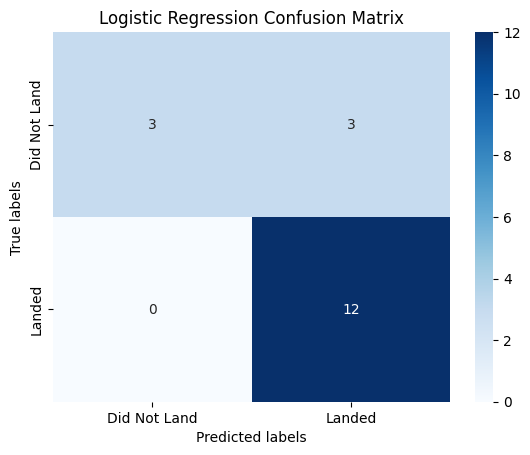

In [11]:
yhat_lr = logreg_cv.predict(X_test)
accuracy_lr = accuracy_score(Y_test, yhat_lr)
print('Logistic Regression Test Accuracy:', accuracy_lr)
plot_confusion_matrix(Y_test, yhat_lr, title='Logistic Regression Confusion Matrix')

---

## Model 2: Support Vector Machine (SVM)

In [12]:
parameters_svm = {
    'kernel': ('linear', 'rbf', 'poly', 'sigmoid'),
    'C': np.logspace(-3, 3, 5),
    'gamma': ('scale', 'auto')
}

svm = SVC()
svm_cv = GridSearchCV(svm, parameters_svm, cv=10)
svm_cv.fit(X_train, Y_train)

print('Tuned hyperparameters (best parameters):', svm_cv.best_params_)
print('Accuracy (CV):', svm_cv.best_score_)

Tuned hyperparameters (best parameters): {'C': np.float64(1.0), 'gamma': 'scale', 'kernel': 'sigmoid'}
Accuracy (CV): 0.8482142857142858


SVM Test Accuracy: 0.8333333333333334


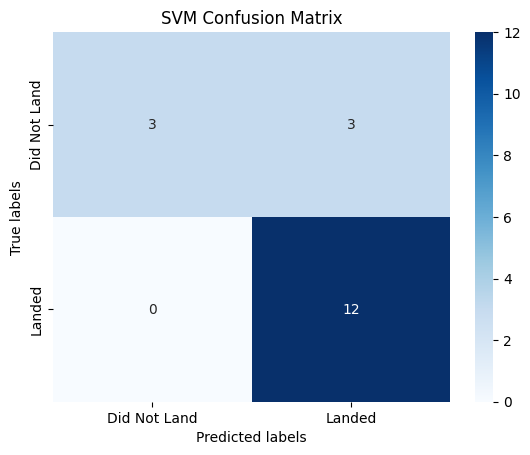

In [13]:
yhat_svm = svm_cv.predict(X_test)
accuracy_svm = accuracy_score(Y_test, yhat_svm)
print('SVM Test Accuracy:', accuracy_svm)
plot_confusion_matrix(Y_test, yhat_svm, title='SVM Confusion Matrix')

---

## Model 3: Decision Tree

In [14]:
parameters_tree = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [2, 4, 6, 8, 10],
    'min_samples_leaf': [1, 2, 4],
    'min_impurity_decrease': [0.0, 0.1, 0.2]
}

tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(tree, parameters_tree, cv=10)
tree_cv.fit(X_train, Y_train)

print('Tuned hyperparameters (best parameters):', tree_cv.best_params_)
print('Accuracy (CV):', tree_cv.best_score_)

Tuned hyperparameters (best parameters): {'criterion': 'gini', 'max_depth': 4, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 4, 'splitter': 'best'}
Accuracy (CV): 0.8857142857142858


Decision Tree Test Accuracy: 0.8333333333333334


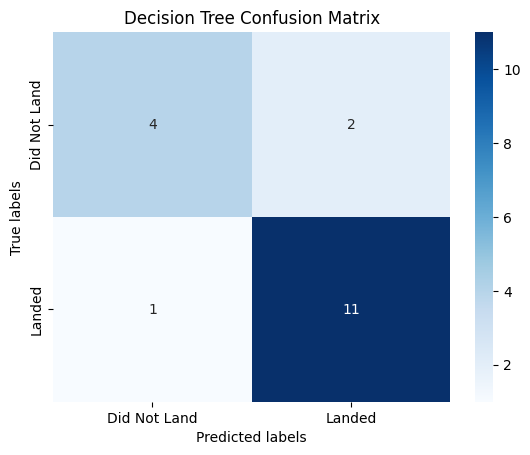

In [15]:
yhat_tree = tree_cv.predict(X_test)
accuracy_tree = accuracy_score(Y_test, yhat_tree)
print('Decision Tree Test Accuracy:', accuracy_tree)
plot_confusion_matrix(Y_test, yhat_tree, title='Decision Tree Confusion Matrix')

---

## Model 4: K-Nearest Neighbors (KNN)

In [16]:
parameters_knn = {
    'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]
}

knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, parameters_knn, cv=10)
knn_cv.fit(X_train, Y_train)

print('Tuned hyperparameters (best parameters):', knn_cv.best_params_)
print('Accuracy (CV):', knn_cv.best_score_)

Tuned hyperparameters (best parameters): {'algorithm': 'auto', 'n_neighbors': 3, 'p': 1}
Accuracy (CV): 0.8339285714285714


KNN Test Accuracy: 0.7777777777777778


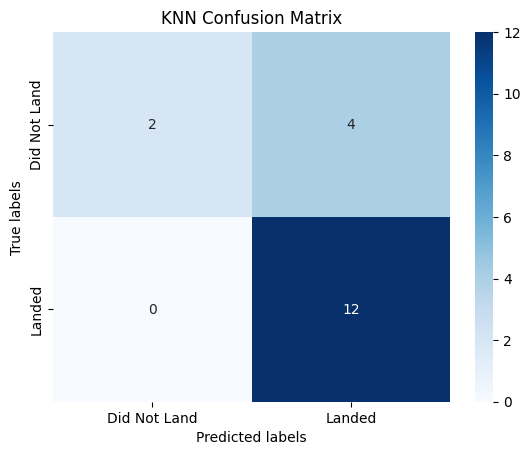

In [17]:
yhat_knn = knn_cv.predict(X_test)
accuracy_knn = accuracy_score(Y_test, yhat_knn)
print('KNN Test Accuracy:', accuracy_knn)
plot_confusion_matrix(Y_test, yhat_knn, title='KNN Confusion Matrix')

---

## Model Comparison

Compare test accuracy across all four models.

In [18]:
results = {
    'Logistic Regression': accuracy_lr,
    'SVM': accuracy_svm,
    'Decision Tree': accuracy_tree,
    'KNN': accuracy_knn
}

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Test Accuracy'])
results_df = results_df.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print(results_df)

                 Model  Test Accuracy
0  Logistic Regression       0.833333
1                  SVM       0.833333
2        Decision Tree       0.833333
3                  KNN       0.777778


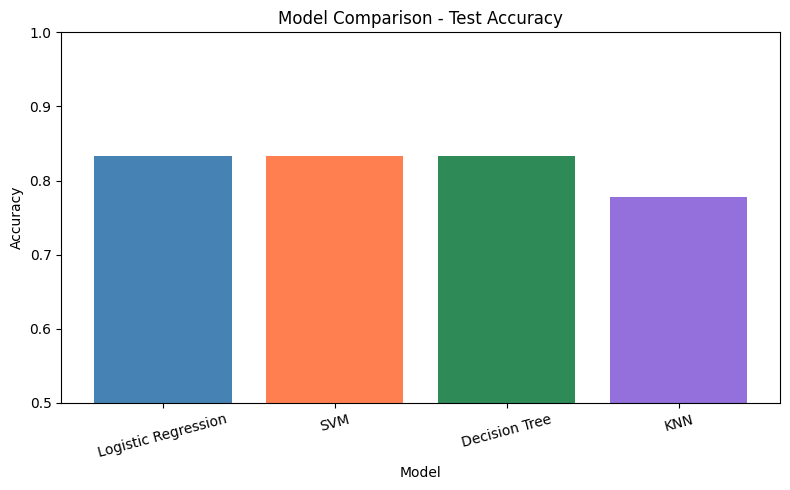

Best model: Logistic Regression with accuracy 0.8333


In [19]:
plt.figure(figsize=(8, 5))
plt.bar(results_df['Model'], results_df['Test Accuracy'], color=['steelblue', 'coral', 'seagreen', 'mediumpurple'])
plt.ylim(0.5, 1.0)
plt.title('Model Comparison - Test Accuracy')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

best_model = results_df.iloc[0]
print(f"Best model: {best_model['Model']} with accuracy {best_model['Test Accuracy']:.4f}")

## Summary

In this lab, we trained and compared four classification models to predict Falcon 9 first stage landing success:

- **Logistic Regression** — tuned `C` via GridSearchCV
- **SVM** — tuned `kernel`, `C`, and `gamma`
- **Decision Tree** — tuned `criterion`, `max_depth`, and `min_samples_leaf`
- **KNN** — tuned `n_neighbors`, `algorithm`, and `p`

All models were evaluated on a held-out test set (20%) after 10-fold cross-validation on the training set.

## Authors

IBM Data Science Professional Certificate — Applied Data Science Capstone